Total images in external dataset: 55900

--- Evaluating Fold 1 ---
Number of images evaluated: 55900
Acc: 0.9996, Prec: 0.9992, Rec: 0.9999, F1: 0.9996, AUC: 1.0000
Confusion Matrix (counts):
[[29797    20]
 [    3 26080]]


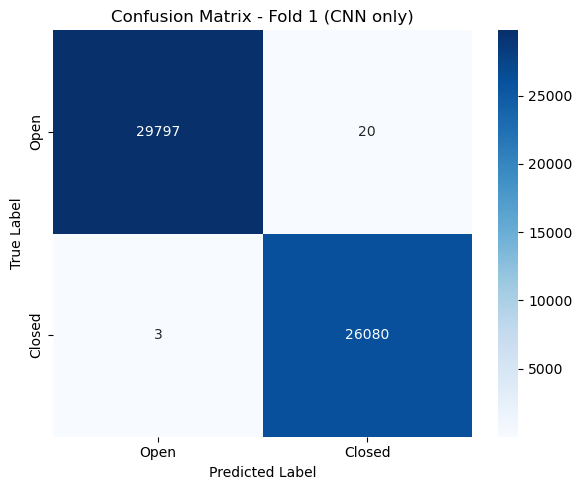


--- Evaluating Fold 2 ---
Number of images evaluated: 55900
Acc: 0.9996, Prec: 0.9992, Rec: 0.9999, F1: 0.9996, AUC: 0.9999
Confusion Matrix (counts):
[[29797    20]
 [    3 26080]]


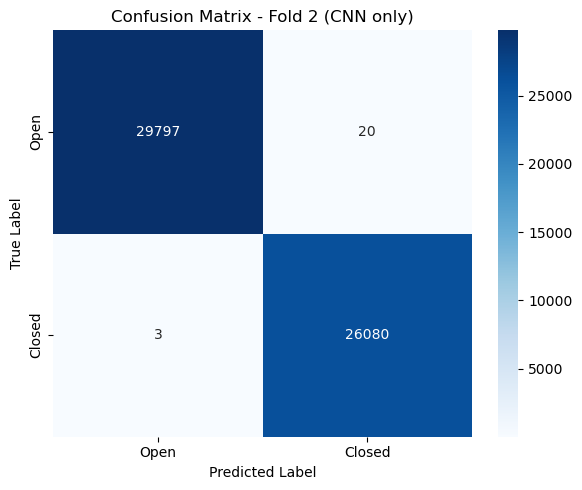


--- Evaluating Fold 3 ---
Number of images evaluated: 55900
Acc: 0.9978, Prec: 0.9992, Rec: 0.9961, F1: 0.9976, AUC: 0.9999
Confusion Matrix (counts):
[[29797    20]
 [  103 25980]]


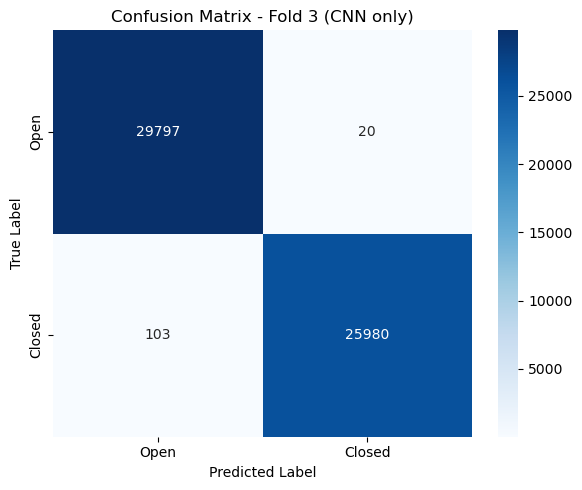


--- Evaluating Fold 4 ---
Number of images evaluated: 55900
Acc: 0.9996, Prec: 0.9992, Rec: 0.9999, F1: 0.9996, AUC: 0.9999
Confusion Matrix (counts):
[[29797    20]
 [    3 26080]]


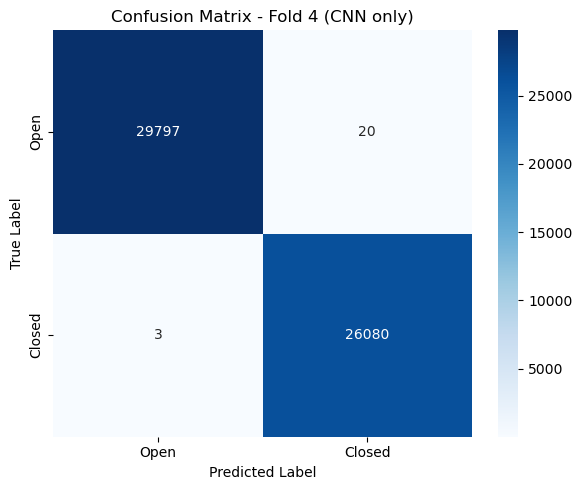


--- Evaluating Fold 5 ---
Number of images evaluated: 55900
Acc: 0.9978, Prec: 0.9992, Rec: 0.9961, F1: 0.9976, AUC: 0.9999
Confusion Matrix (counts):
[[29797    20]
 [  103 25980]]


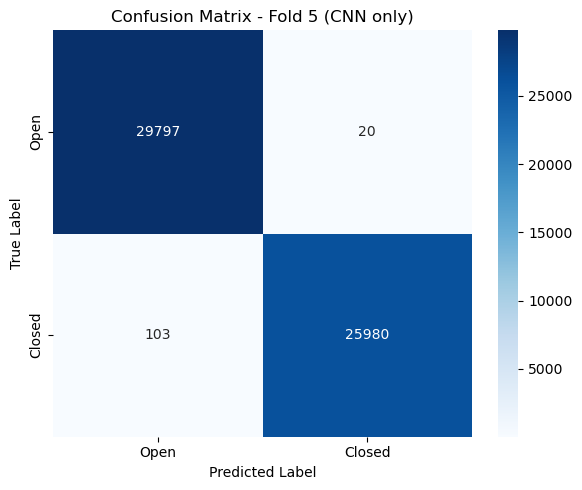


--- Average Confusion Matrix (counts averaged over folds) ---
[[2.9797e+04 2.0000e+01]
 [4.3000e+01 2.6040e+04]]


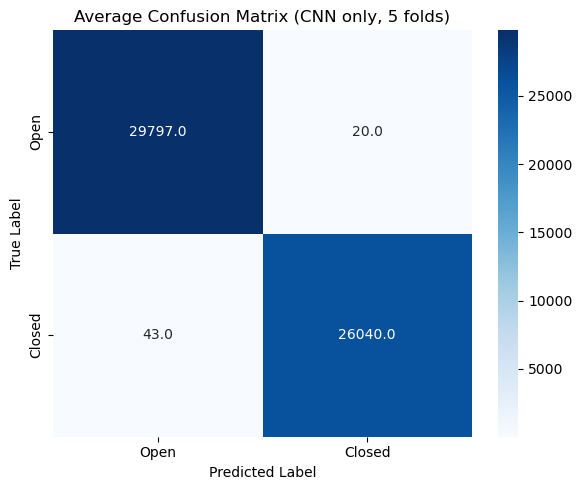


--- Normalized Average Confusion Matrix (row percentages) ---
[[9.99329242e-01 6.70758292e-04]
 [1.64858337e-03 9.98351417e-01]]


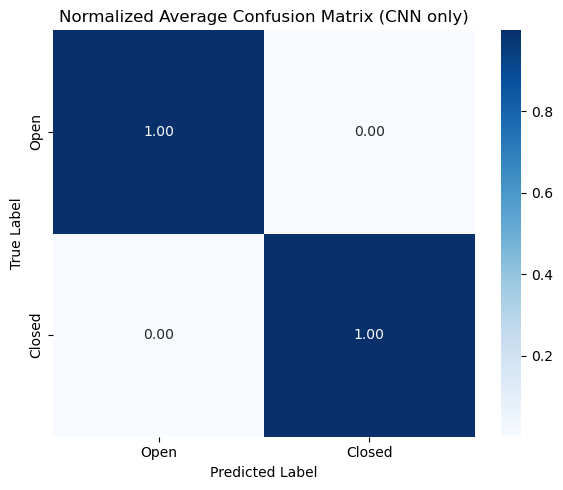


EXTERNAL VALIDATION RESULTS (Average over folds) - CNN ONLY
Avg Accuracy:  0.9989
Avg Precision: 0.9992
Avg Recall:    0.9984
Avg F1-Score:  0.9988
Avg AUC:       0.9999

Global AUC (all predictions): 0.9999


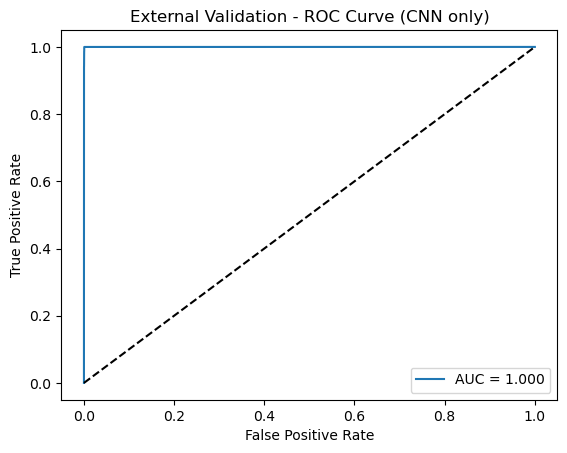

In [2]:
import os
import torch
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import seaborn as sns

# ------------------------------
# 1. Device
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# 2. Model Definition (must match training)
# ------------------------------
class ResidualBlock(torch.nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(in_ch, in_ch, 3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(in_ch)
        self.conv2 = torch.nn.Conv2d(in_ch, in_ch, 3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(in_ch)

    def forward(self, x):
        identity = x
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return torch.relu(out)

class ImprovedCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 16, 3, padding=1),
            torch.nn.BatchNorm2d(16),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(16, 32, 3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )
        self.res = ResidualBlock(32)
        self.layer3 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(64 * 8 * 8, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.res(x)
        x = self.layer3(x)
        x = self.fc(x)
        return x

# ------------------------------
# 3. Dataset Class (test transform only)
# ------------------------------
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

class EyeDatasetExternal(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.images, self.labels = [], []
        for label, cls in enumerate(["open", "closed"]):
            path = os.path.join(root_dir, cls)
            for img in os.listdir(path):
                if img.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.images.append(os.path.join(path, img))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx], 0)
        img = cv2.equalizeHist(img)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ------------------------------
# 4. Evaluate a single model (no EAR)
# ------------------------------
def evaluate_model(model_path, dataset, batch_size=32):
    """
    Load a saved model and evaluate on the given dataset.
    Uses only the CNN output (softmax probability) for class 1.
    Returns: y_true, y_pred, y_score (probability for class 1)
    """
    model = ImprovedCNN().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    y_true, y_pred, y_score = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            prob_closed = probs[:, 1].cpu().numpy()

            preds = (prob_closed >= 0.5).astype(int)

            y_true.extend(y.numpy())
            y_pred.extend(preds)
            y_score.extend(prob_closed)

    return y_true, y_pred, y_score

# ------------------------------
# 5. Helper: plot confusion matrix with seaborn
# ------------------------------
def plot_confusion_matrix(cm, classes=['Open', 'Closed'], title='Confusion Matrix',
                          cmap='Blues', annot=True, fmt='d', save_path=None):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=annot, fmt=fmt, cmap=cmap,
                xticklabels=classes, yticklabels=classes,
                cbar=True)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

# ------------------------------
# 6. Main: run validation for all folds
# ------------------------------
external_root = "D:/Real_Dataset/Real_Dataset"   # <-- SET YOUR PATH
models_dir = "C:/Users/DELL/Desktop/m"           # <-- folder with fold models

# Create the dataset once
dataset = EyeDatasetExternal(external_root, transform=test_transform)
print(f"Total images in external dataset: {len(dataset)}")   # <-- NEW

fold_metrics = []
all_cm = []
all_true = []
all_score = []

for fold in range(1, 6):
    model_path = os.path.join(models_dir, f"model_fold_{fold}.pth")
    if not os.path.exists(model_path):
        print(f"Warning: {model_path} not found. Skipping.")
        continue

    print(f"\n--- Evaluating Fold {fold} ---")
    y_true, y_pred, y_score = evaluate_model(model_path, dataset)

    # Number of images evaluated (same as len(dataset) for this fold)
    print(f"Number of images evaluated: {len(y_true)}")   # <-- NEW

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    auc = roc_auc_score(y_true, y_score)

    fold_metrics.append((acc, prec, rec, f1, auc))
    print(f"Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix (counts):")
    print(cm)
    all_cm.append(cm)

    # Colored confusion matrix for this fold
    plot_confusion_matrix(
        cm,
        classes=['Open', 'Closed'],
        title=f'Confusion Matrix - Fold {fold} (CNN only)',
        cmap='Blues',
        fmt='d',
        save_path=f'confusion_matrix_fold_{fold}_noEAR.png'
    )

    all_true.extend(y_true)
    all_score.extend(y_score)

# ------------------------------
# 7. Average confusion matrix across folds
# ------------------------------
if all_cm:
    sum_cm = np.sum(all_cm, axis=0)
    avg_cm = sum_cm / len(all_cm)
    print("\n--- Average Confusion Matrix (counts averaged over folds) ---")
    print(avg_cm)

    plot_confusion_matrix(
        avg_cm,
        classes=['Open', 'Closed'],
        title=f'Average Confusion Matrix (CNN only, {len(all_cm)} folds)',
        cmap='Blues',
        fmt='.1f',
        save_path='average_confusion_matrix_noEAR.png'
    )

    # Normalized (row percentages)
    row_sums = avg_cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1e-9
    norm_avg_cm = avg_cm / row_sums
    print("\n--- Normalized Average Confusion Matrix (row percentages) ---")
    print(norm_avg_cm)
    plot_confusion_matrix(
        norm_avg_cm,
        classes=['Open', 'Closed'],
        title=f'Normalized Average Confusion Matrix (CNN only)',
        cmap='Blues',
        fmt='.2f',
        save_path='normalized_average_confusion_matrix_noEAR.png'
    )

# ------------------------------
# 8. Overall performance
# ------------------------------
if fold_metrics:
    print("\n" + "="*50)
    print("EXTERNAL VALIDATION RESULTS (Average over folds) - CNN ONLY")
    print("="*50)
    avg_acc = np.mean([m[0] for m in fold_metrics])
    avg_prec = np.mean([m[1] for m in fold_metrics])
    avg_rec = np.mean([m[2] for m in fold_metrics])
    avg_f1 = np.mean([m[3] for m in fold_metrics])
    avg_auc = np.mean([m[4] for m in fold_metrics])
    print(f"Avg Accuracy:  {avg_acc:.4f}")
    print(f"Avg Precision: {avg_prec:.4f}")
    print(f"Avg Recall:    {avg_rec:.4f}")
    print(f"Avg F1-Score:  {avg_f1:.4f}")
    print(f"Avg AUC:       {avg_auc:.4f}")

    # Global ROC
    if all_true:
        global_auc = roc_auc_score(all_true, all_score)
        print(f"\nGlobal AUC (all predictions): {global_auc:.4f}")

        fpr, tpr, _ = roc_curve(all_true, all_score)
        plt.figure()
        plt.plot(fpr, tpr, label=f'AUC = {global_auc:.3f}')
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('External Validation - ROC Curve (CNN only)')
        plt.legend()
        plt.show()